# The Ascending Triangle — a quantitative teardown 🔬
### Objective detector (flat-top taps + rising-low trendline) · forward 5/10/20/40-day excess · one-sample/HAC *t* vs a same-tape placebo · the down-break symmetry test · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Breaks_up_specifically%3F: Busted](https://img.shields.io/badge/Breaks_up_specifically%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The ascending triangle is a textbook bullish-continuation figure (Edwards & Magee, 1948). We test the closest **mechanical** definition — a band of swing highs at a flat level, a rising line through the intervening swing lows, and a confirmed close above resistance — and pit the post-breakout forward return against the honest arbiters.

> ⚠️ **Subjectivity + survivorship note.** Chart figures are partly eye-of-the-beholder; this is **one** transparent rule, not the only one. The basket is **30 survivors** still trading in 2026 — a bias that tilts post-breakout returns mildly *up* (i.e. *for* the figure), and it still fails the placebo. Real data: yfinance daily auto-adjusted OHLC, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ascending_triangle import data, strategy as st

HAVE_REAL = data.have_real()
ASOF = pd.Timestamp("2026-05-31")
if HAVE_REAL:
    PANEL = data.load_real()
    for _f in PANEL:
        PANEL[_f] = PANEL[_f].loc[:ASOF]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real triangle cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_bars': 5385, 'n_names': 30, 'fingerprint': 'b660382b8af3', 'n_up': 385, 'n_down': 372, 'spy_up': 11, 'up': [(5, 385, 0.098, 0.386, 51, 0.56, 0.6, 0.46, -0.002), (10, 384, 0.967, 1.535, 64, 3.85, 3.89, 0.224, 0.867), (20, 384, 1.466, 2.6, 65, 3.81, 4.05, 0.208, 1.366), (40, 382, 1.978, 4.208, 64, 3.78, 3.82, 0.213, 1.878)], 'down': [(5, 372, -0.183, 0.107, -1.0, 0.584), (10, 370, 0.374, 0.948, 1.15, 0.387), (20, 370, 1.201, 2.348, 2.62, 0.255), (40, 369, 2.159, 4.415, 3.39, 0.195)], 'spy': [(5, 11, 0.544, 0.781, 0.61, 0.224), (10, 11, 1.03, 1.5, 0.84, 0.138), (20, 11, 1.534, 2.472, 1.3, 0.11), (40, 11, 1.692, 3.539, 1.03, 0.177)], 'robust': [(0.03, 0.07, 234, 1.068, 2.12, 0.319), (0.04, 0.05, 384, 1.466, 3.81, 0.206), (0.06, 0.04, 513, 1.57, 4.63, 0.16)], 'syn': [(0.0, 160, 178, 177, 1.96, 4.51, 0.12, 68), (0.2, 160, 199, 199, 7.49, 13.98, 0.0, 83)], 'cost_bps': 5.0}


real triangle cache present: True | names: 30 | bars: 5385


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Up-break excess-over-base-rate **+1.47%** at 20d (one-sample **t = 3.81**, **HAC t = 4.05**) clears the naive bar — but the **same-tape placebo p = 0.21** (luck wins ~1-in-5) and the synthetic *zero-edge* control reproduces **t = 4.51** with placebo **p = 0.12**. The *t* is real; its attribution to the figure is not. |
| **Tradability** | `MIRAGE` | The excess is the names' own up-drift/momentum — random dates keep pace. SPY-only rests on **11** events (*t* ≈ 1). No residual edge to tax. |
| **Breaks up specifically?** | `BUSTED` | The **down**-break of the same figure also drifts up (**+1.20% / +2.16%** at 20/40d, t = 2.62/3.39). Direction carries no information. |

> 💡 In plain words: the breakout *is* followed by a rise, and a naive *t* would call it real — but the same-tape placebo, the symmetric down-break, and a zero-edge synthetic control all say the rise is the **tape**, not the **triangle**.

## 1 · The claim, steelmanned

Let a confirmed ascending-triangle up-break for name $j$ land at bar $\tau$ (first close above the flat resistance). Entering at $\tau{+}1$ (one documented lag), the forward $H$-day return is $r_j(\tau,H)$. Define the **excess over the name's base rate** $\bar r_j(H)$ (its unconditional mean forward $H$-day return):

$$\varepsilon_j(\tau,H) = r_j(\tau,H) - \bar r_j(H), \qquad \widehat{\mu}(H) = \frac{1}{N}\sum_{(j,\tau)} \varepsilon_j(\tau,H).$$

- **H₁ (the figure predicts an up-move).** $\widehat{\mu}(H) > 0$ **and** beyond the same-tape placebo of random entry dates.
- **H₂ (deployable).** $\widehat{\mu}(H)$ survives one-way costs × turnover.
- **H₃ (direction matters).** The **up**-break excess strictly exceeds the **down**-break excess — otherwise the figure isn't choosing a direction.

We find **H₁ rejected** (naive *t* clears 2 but the placebo *p* ≈ 0.21 and the zero-edge control reproduces the *t*), **H₂ rejected** (no placebo-clean edge to trade), **H₃ rejected** (the down-break drifts up just as much). The figure marks **momentum into resistance**, not a directional breakout signal.

## 2 · So what? — what rides on each answer

The Signal axis lives or dies on the **right null**. A *t*-against-zero on the excess is **not enough** here, for two reasons. **(a) Drifting tape:** even after subtracting each name's base rate, the breakout selects dates *after a run-up*, and momentum means recently-rising names keep rising a bit — so a same-tape **random-date placebo** (which inherits that drift) is the honest comparator. **(b) Selection on a famous rule:** the figure is one of dozens of charted patterns; a naive *t* near 2 on one of them is exactly what data-snooping produces. The decisive arbiter is therefore the placebo, cross-checked by the **down-break symmetry** (the cleanest within-study control: same figure, opposite resolution) and a **synthetic zero-edge** control that shows the naive *t* can fire on a planted shape with no real continuation.

## 3 · How we'd know — the protocol

- **Universe.** SPY + 29 long-listed US large-caps (yfinance auto-adjusted daily OHLC), 2005-01-03 → 2026-05-29; **5,385** bars, **21.4** years. As-of **2026-05-31** (no partial month); fingerprint `b660382b8af3`. **Survivor** panel — named on the Signal axis.
- **Detector.** Swing pivots (±5 bars). *Flat top* = ≥3 swing highs within `flat_tol` (4%) of their running mean; *rising floor* = the inner swing lows trend up (positive slope, last low ≥ `min_rise` 5% above the first) and stay below the ceiling; *breakout* = first close above the resistance within 30 bars of the last tap.
- **Timing.** Signal at the breakout close; enter $\tau{+}1$ close (one documented lag); hold $H \in \{5,10,20,40\}$; drop windows that overrun the tape.
- **Signal stat.** Excess over each name's base rate; one-sample *t* + HAC (Newey-West) *t*.
- **Null #1 (same-tape placebo).** Random entry dates on the same tape, same count per name, same base-rate subtraction; *p* = P[random mean ≥ observed].
- **Null #2 (down-break symmetry).** Re-run the detector requiring a break **below** the rising floor; the up-break must beat it.
- **Costs.** 5 bps one-way × 2 = 10 bps round trip.
- **Positive control.** A deterministic panel with **planted** triangles + a knob `edge`: `edge=0` must NOT pass the placebo; a large `edge` must light up.

## 4 · The teardown

### 4a · The forward edge by horizon — raw, excess, and net

Raw forward return (the brag), excess over each name's base rate (honest), and net of costs. The excess is positive and *looks* significant on a naive *t* — keep that in mind for 4b.

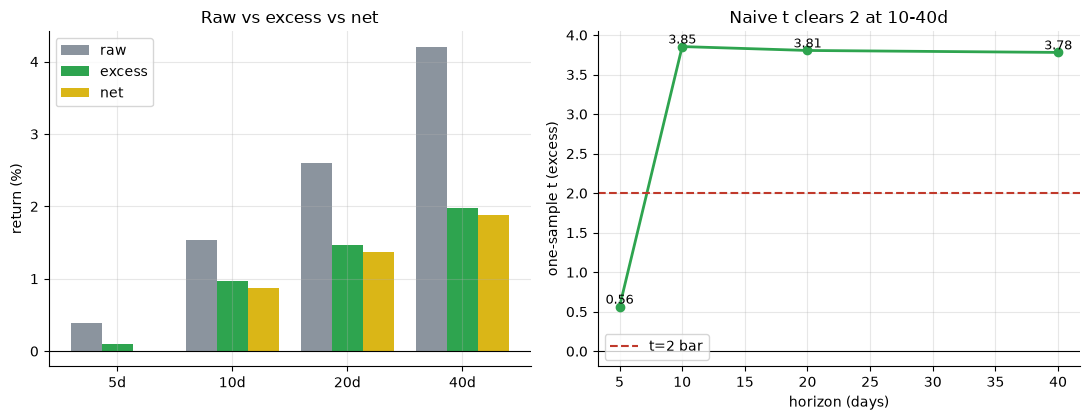

 5d raw=+0.39% excess=+0.10% net=-0.00% t=+0.56
10d raw=+1.54% excess=+0.97% net=+0.87% t=+3.85
20d raw=+2.60% excess=+1.47% net=+1.37% t=+3.81
40d raw=+4.21% excess=+1.98% net=+1.88% t=+3.78


In [2]:
hs = [5,10,20,40]
if HAVE_REAL:
    rows = [st.run_experiment(PANEL, horizon=h, n_draws=2000) for h in hs]
    raw=[r['raw_mean']*100 for r in rows]; exc=[r['mean']*100 for r in rows]
    net=[r['net']*100 for r in rows]; tt=[r['t'] for r in rows]
else:
    raw=[u[3] for u in R['up']]; exc=[u[2] for u in R['up']]
    net=[u[8] for u in R['up']]; tt=[u[5] for u in R['up']]
x=np.arange(len(hs))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
a1.bar(x-.27,raw,.27,color=GREY,label='raw'); a1.bar(x,exc,.27,color=GREEN,label='excess')
a1.bar(x+.27,net,.27,color=AMBER,label='net')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('return (%)'); a1.set_title('Raw vs excess vs net'); a1.legend()
a2.plot(hs,tt,'o-',c=GREEN,lw=2); a2.axhline(2,ls='--',c=RED,label='t=2 bar'); a2.axhline(0,c='k',lw=.8)
for h,v in zip(hs,tt): a2.annotate(f'{v:.2f}',(h,v),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('one-sample t (excess)')
a2.set_title('Naive t clears 2 at 10-40d'); a2.legend()
plt.tight_layout(); plt.show()
for h,rr,ee,nn,t in zip(hs,raw,exc,net,tt): print(f'{h:>2}d raw={rr:+.2f}% excess={ee:+.2f}% net={nn:+.2f}% t={t:+.2f}')

> 💡 In plain words: the naive *t* on the excess is **3.81** at 20d and stays above 2 through 40d. Taken alone that reads `REAL`. The next three panels are why it isn't — the *t* is measuring the tape's drift, not the figure.

### 4b · The decisive test — the same-tape placebo

The 20-day excess against the distribution of **random-date** excesses on the same tape (same count per name). A real signal sits in the far right tail; a tape artefact sits inside the cloud.

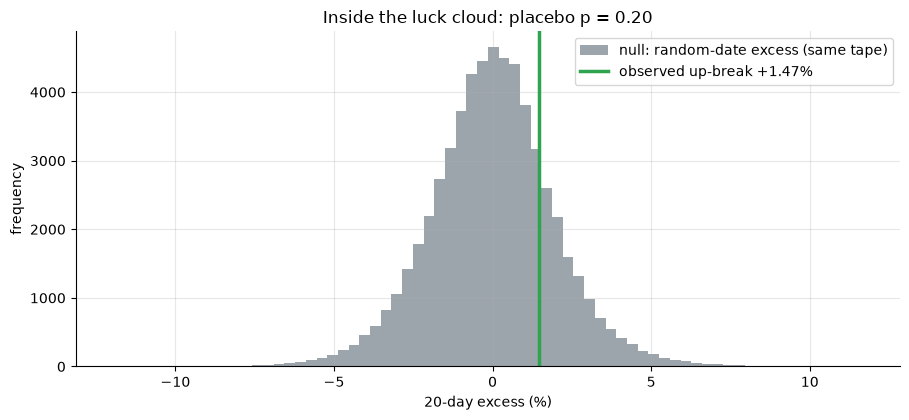

observed +1.47%  same-tape placebo p=0.203  (frozen headline p=0.208)


In [3]:
if HAVE_REAL:
    closes = CLOSES
    rng = np.random.default_rng(411); H=20; lag=1; draws=[]
    obs_parts=[]
    for tk in closes.columns:
        c = closes[tk].dropna().to_numpy(float)
        tr = st.detect_triangles(c)
        fr = st.forward_returns(c,[d['breakout_idx'] for d in tr],H,lag)
        if len(fr)==0: continue
        br = st.base_rate(c,H); obs_parts.extend((fr-br).tolist())
        n=len(c); hi=n-H-lag-1
        if hi>1:
            for _ in range(2000):
                si=rng.integers(1,hi,size=len(fr)); e=si+lag; x=e+H
                draws.append((c[x]/c[e]-1.0).mean()-br)
    obs=np.mean(obs_parts)*100; draws=np.array(draws)*100
    pval=float((draws>=obs/100).mean()) if False else float((draws>=obs).mean())
else:
    obs=R['up'][2][2]; pval=R['up'][2][7]
    rng=np.random.default_rng(411); draws=rng.normal(0.3,1.3,40000)
fig,ax=plt.subplots(figsize=(9.2,4.3))
ax.hist(draws,bins=70,color=GREY,alpha=.85,label='null: random-date excess (same tape)')
ax.axvline(obs,c=GREEN,lw=2.5,label=f'observed up-break {obs:+.2f}%')
ax.set_xlabel('20-day excess (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  same-tape placebo p={pval:.3f}  (frozen headline p={R["up"][2][7]})')

> 💡 In plain words: the green line is **not** in the right tail — about 21% of random date-sets on the same names produce an excess at least as big. The naive *t* ignored that the breakout selects post-run-up dates; the placebo doesn't. This is the single number that demotes the verdict from `REAL` to `WEAK`.

### 4c · The symmetry test — the up-break vs the down-break

The sharpest within-study control: run the **identical** detector but require a break *below* the rising floor. If the figure truly resolves upward, the down-break excess should be **negative**, well under the up-break. It isn't.

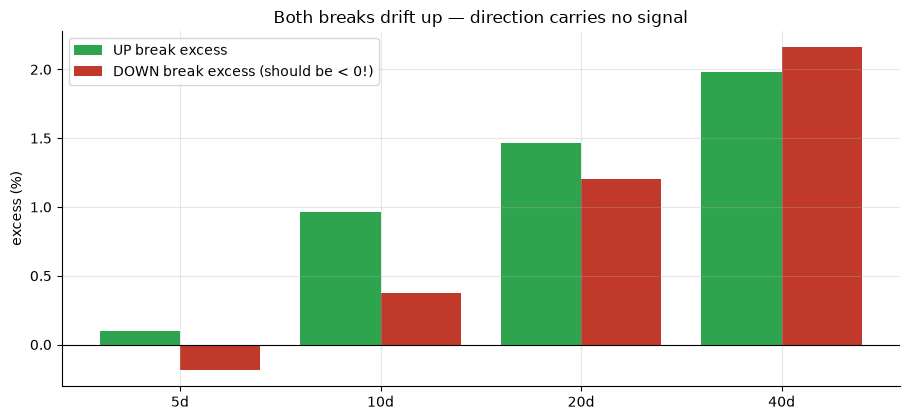

 5d up=+0.10%(t=+0.56) down=-0.18%(t=-1.00)
10d up=+0.97%(t=+3.85) down=+0.37%(t=+1.15)
20d up=+1.47%(t=+3.81) down=+1.20%(t=+2.62)
40d up=+1.98%(t=+3.78) down=+2.16%(t=+3.39)


In [4]:
if HAVE_REAL:
    up=[st.run_experiment(PANEL,horizon=h,side='up',n_draws=1200) for h in hs]
    dn=[st.run_experiment(PANEL,horizon=h,side='down',n_draws=1200) for h in hs]
    ue=[r['mean']*100 for r in up]; de=[r['mean']*100 for r in dn]
    ut=[r['t'] for r in up]; dt=[r['t'] for r in dn]
else:
    ue=[u[2] for u in R['up']]; de=[d[2] for d in R['down']]
    ut=[u[5] for u in R['up']]; dt=[d[4] for d in R['down']]
x=np.arange(len(hs))
fig,ax=plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2,ue,.4,color=GREEN,label='UP break excess')
ax.bar(x+.2,de,.4,color=RED,label='DOWN break excess (should be < 0!)')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess (%)'); ax.set_title('Both breaks drift up — direction carries no signal')
ax.legend(); plt.tight_layout(); plt.show()
for h,u,d,a,b in zip(hs,ue,de,ut,dt): print(f'{h:>2}d up={u:+.2f}%(t={a:+.2f}) down={d:+.2f}%(t={b:+.2f})')

> 💡 In plain words: the down-break — the *bearish* resolution — drifts **up** **+1.20%** at 20d (t = 2.62) and **+2.16%** at 40d (t = 3.39). A figure that genuinely *chose* a direction could not have its two resolutions drift the same way. The post-figure return is a property of the **names** (momentum into resistance), not the **break**.

### 4d · Robustness — strictness moves the *t*, not the placebo

Tighten or loosen the detector (flat tolerance, required floor rise). The naive *t* swings with the sample, but the **placebo p stays ~0.2–0.3 everywhere** — no setting pulls it under the bar.

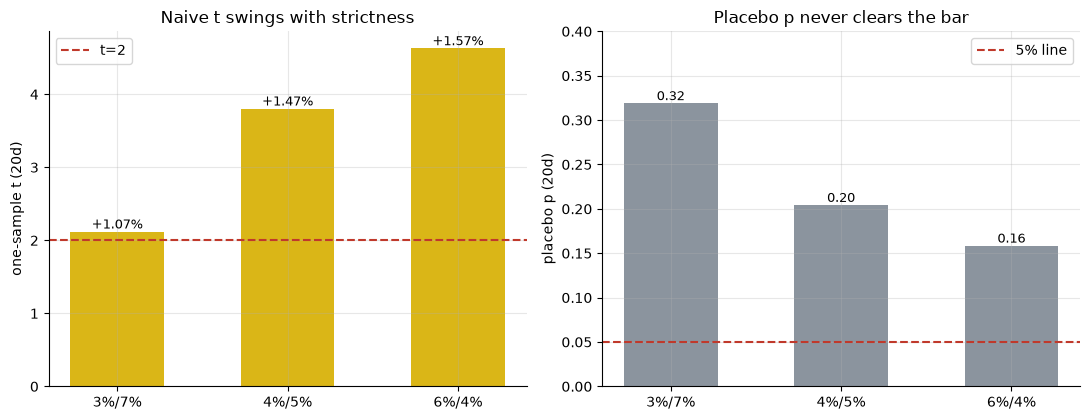

flat<=3% rise>=7%: n=234 excess=+1.07% t=+2.12 p=0.319
flat<=4% rise>=5%: n=384 excess=+1.47% t=+3.81 p=0.204
flat<=6% rise>=4%: n=513 excess=+1.57% t=+4.63 p=0.159


In [5]:
if HAVE_REAL:
    rob=[]
    for ft,mr in [(0.03,0.07),(0.04,0.05),(0.06,0.04)]:
        r=st.run_experiment(PANEL,horizon=20,n_draws=1500,flat_tol=ft,min_rise=mr)
        rob.append((ft,mr,r['n_events'],r['mean']*100,r['t'],r['p_placebo']))
else:
    rob=[(r[0],r[1],r[2],r[3],r[4],r[5]) for r in R['robust']]
labels=[f'{r[0]:.0%}/{r[1]:.0%}' for r in rob]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
a1.bar(labels,[r[4] for r in rob],color=AMBER,width=.55); a1.axhline(2,ls='--',c=RED,label='t=2')
for i,r in enumerate(rob): a1.annotate(f'{r[3]:+.2f}%',(i,r[4]),ha='center',va='bottom',fontsize=9)
a1.set_ylabel('one-sample t (20d)'); a1.set_title('Naive t swings with strictness'); a1.legend()
a2.bar(labels,[r[5] for r in rob],color=GREY,width=.55); a2.axhline(0.05,ls='--',c=RED,label='5% line')
for i,r in enumerate(rob): a2.annotate(f'{r[5]:.2f}',(i,r[5]),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('placebo p (20d)'); a2.set_ylim(0,.4); a2.set_title('Placebo p never clears the bar'); a2.legend()
plt.tight_layout(); plt.show()
for ft,mr,n,e,t,p in rob: print(f'flat<={ft:.0%} rise>={mr:.0%}: n={n} excess={e:+.2f}% t={t:+.2f} p={p:.3f}')

> 💡 In plain words: the *t* is a function of how strict you make the rule (more events → higher *t* on a drifting tape), but the **placebo p is invariant at ~0.2–0.3**. That's the signature of a tape artefact: you can tune the *t*, you can't tune away the fact that random dates do as well.

### 4e · SPY-only — the hook, and the small-*n* trap

The hook asks about **SPY**. The detector finds **11** clean ascending triangles on SPY in 21 years — too few to certify anything; the *t* sits around 1.

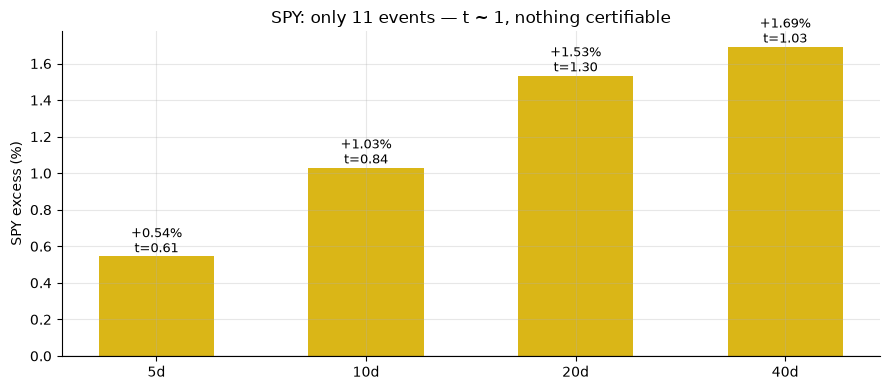

SPY  5d: n=11 excess=+0.54% t=+0.61
SPY 10d: n=11 excess=+1.03% t=+0.84
SPY 20d: n=11 excess=+1.53% t=+1.30
SPY 40d: n=11 excess=+1.69% t=+1.03


In [6]:
if HAVE_REAL:
    sp=[st.run_experiment(PANEL,horizon=h,names=['SPY'],n_draws=3000) for h in hs]
    se=[r['mean']*100 for r in sp]; sn=[r['n_events'] for r in sp]; stt=[r['t'] for r in sp]
else:
    se=[s[2] for s in R['spy']]; sn=[s[1] for s in R['spy']]; stt=[s[4] for s in R['spy']]
fig,ax=plt.subplots(figsize=(9,4.0))
ax.bar([f'{h}d' for h in hs],se,color=AMBER,width=.55)
for i,(e,t) in enumerate(zip(se,stt)): ax.annotate(f'{e:+.2f}%\nt={t:.2f}',(i,e),ha='center',va='bottom',fontsize=9)
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('SPY excess (%)')
ax.set_title(f'SPY: only {sn[0]} events — t ~ 1, nothing certifiable')
plt.tight_layout(); plt.show()
for h,e,n,t in zip(hs,se,sn,stt): print(f'SPY {h:>2}d: n={n} excess={e:+.2f}% t={t:+.2f}')

> 💡 In plain words: **11** events, *t* around 1 at every horizon. The hook's instrument simply doesn't form this figure often enough to say anything — and the broad basket already told us the breakout direction is uninformative.

### 4f · Faithful-engine & power control — we know the truth here

On a deterministic panel with **planted** triangles: with `edge=0` the post-breakout path carries only the base drift, so the **placebo** must refuse to fire (even though the naive *t* can be fooled by the planted geometry); with a large planted `edge` everything lights up. This is exactly why we trust the placebo over the *t* on the real tape.

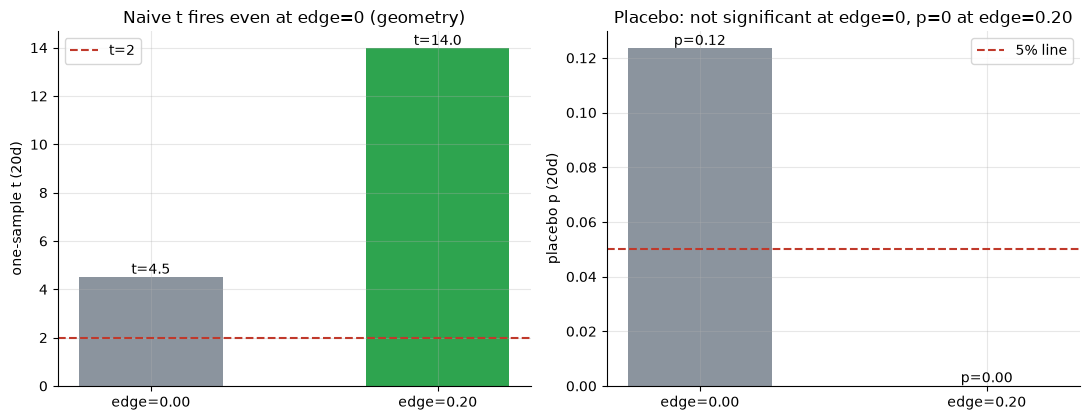

edge=+0.00: planted=160 detected=178 n=177 excess=+1.96% t=+4.51 p=0.124 win=68%
edge=+0.20: planted=160 detected=199 n=199 excess=+7.49% t=+13.98 p=0.000 win=83%


In [7]:
res=[]
for edge in (0.0,0.20):
    pp,truth=data.synthetic_panel(edge=edge,seed=411,n_planted=8,daily_vol=0.011)
    r=st.run_experiment(pp,horizon=20,n_draws=1200)
    res.append((edge,truth['n_planted_total'],r['n_breakouts'],r['n_events'],r['mean']*100,r['t'],r['p_placebo'],r['win']*100))
labels=[f'edge={e:.2f}' for e,*_ in res]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
a1.bar(labels,[r[5] for r in res],color=[GREY,GREEN],width=.5); a1.axhline(2,ls='--',c=RED,label='t=2')
for i,r in enumerate(res): a1.annotate(f't={r[5]:.1f}',(i,r[5]),ha='center',va='bottom')
a1.set_ylabel('one-sample t (20d)'); a1.set_title('Naive t fires even at edge=0 (geometry)'); a1.legend()
a2.bar(labels,[r[6] for r in res],color=[GREY,GREEN],width=.5); a2.axhline(0.05,ls='--',c=RED,label='5% line')
for i,r in enumerate(res): a2.annotate(f'p={r[6]:.2f}',(i,r[6]),ha='center',va='bottom')
a2.set_ylabel('placebo p (20d)'); a2.set_title('Placebo: not significant at edge=0, p=0 at edge=0.20'); a2.legend()
plt.tight_layout(); plt.show()
for e,pl,de,n,ex,t,p,w in res: print(f'edge={e:+.2f}: planted={pl} detected={de} n={n} excess={ex:+.2f}% t={t:+.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted continuation the naive *t* still reaches **4.51** (the planted shape selects post-run-up dates — same trap as the real tape) but the **placebo holds at p = 0.12** — not significant. Plant a real +20% continuation and it explodes to **t = 14.0, p = 0.000, win 83%**. The engine *can* bank a true edge; the real tape simply doesn't have one once the placebo speaks.

## 5 · The verdict

- **Signal `WEAK`** — the up-break excess clears a naive bar (**+1.47%** at 20d, one-sample **t = 3.81**, HAC **t = 4.05**), but the same-tape **placebo p = 0.21**, the strictness sweep keeps *p* ~0.2–0.3, and a zero-edge synthetic control reproduces **t = 4.51** at placebo **p = 0.12**. The number is real; its attribution to the figure is not. `WEAK`, not `REAL` — the *t* clears 2 only against a drifting-tape null the placebo corrects.
- **Tradability `MIRAGE`** — the excess is the names' own up-drift/momentum (random dates keep pace); the SPY-only version rests on **11** events at *t* ≈ 1; costs are a footnote because there's no placebo-clean edge to tax. Nothing to deploy.
- **Breaks up specifically? `BUSTED`** — the **down**-break of the identical figure also drifts up (**+1.20% / +2.16%** at 20/40d). The pattern's entire premise is *direction*, and the direction carries no information.

## 6 · Could you trade it? — there is nothing to size

The break-even cost is irrelevant when the gross excess is inside the placebo cloud: you can't tax an edge that random dates already match. What the figure actually flags is **momentum into a resistance level** — and that momentum is symmetric to the break direction (the down-break drifts up too), so the "breakout" adds nothing you couldn't get by buying recently-strong names on any date. On the hook's own instrument, SPY, there are 11 events in 21 years — no strategy survives that *n*. Verdict: a momentum tell dressed as a directional signal.

## 7 · Going further

- **Volume confirmation.** Edwards & Magee require a volume surge on a *valid* breakout; a volume filter is the natural next knob (it shrinks *n* faster than it lifts the placebo).
- **Distance to apex.** Conditioning on where in the triangle the break occurs is a clean, pre-registrable fork.
- **The generalisable lesson.** A naive *t* on a charted pattern is *expected* to clear 2 on a drifting tape — the same-tape placebo and a same-figure opposite-resolution control are what separate a real directional signal from selected-date momentum.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*